# Phase 2: Hierarchical NLP Inference Pipeline Notebook

This notebook benchmarks the full three-tier inference system with confidence-based routing.
It loads the Phase 1 trained models, defines a callable inference function for each tier,
runs the router across multiple threshold configurations, tests ablation baselines,
and saves results for analysis in Steps 10 and 11.

# Cell 1: Installation

Install all packages required for the pipeline. ONNX Runtime is used for Tier 1 and Tier 2 inference.
Transformers and accelerate are used for Tier 3 (LLM). Scikit-learn and joblib are used to
load the Tier 1 vectorizer and label encoder.

In [12]:
# CELL 1 -- INSTALLATION

import subprocess, sys

# Install PyTorch with CUDA 12.1 support first, before anything else.
# This must come before the general pip installs to avoid pip pulling
# the CPU-only torch build as a dependency of other packages.
# CONFIGURABLE: update the cu121 tag if Colab's CUDA version changes.
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'torchaudio',
    '--index-url', 'https://download.pytorch.org/whl/cu121'
])

packages = [
    'onnxruntime-gpu',  # GPU-enabled ONNX Runtime (replaces onnxruntime)
    'pandas',
    'numpy',
    'scikit-learn',
    'transformers',
    'accelerate',
    'joblib',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All packages installed successfully.')

All packages installed successfully.


# Cell 2: Google Drive Mount

Mount Google Drive to access the shared IOT Group Project folder containing
data, models, and results directories. This ensures all large files stay
synchronized automatically between both students' drives.

In [13]:
# CELL 2 -- GOOGLE DRIVE MOUNT

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


# Cell 3: Imports

Import all required libraries. All heavy imports (torch, transformers) are done here once
so that subsequent cells stay clean and readable.

In [14]:
# CELL 3 -- IMPORTS

import json
import pathlib
import sys
import warnings

import numpy as np
import pandas as pd
import joblib
import onnxruntime as ort
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
print('Imports complete.')
print(f'  PyTorch : {torch.__version__}')
print(f'  CUDA    : {torch.cuda.is_available()}')

Imports complete.
  PyTorch : 2.10.0+cu128
  CUDA    : True


# Cell 4: Project Path Selection

Locate the shared IOT Group Project folder on Google Drive. Uncomment the path
that matches your Drive layout, or use the auto-search function (slow).

In [15]:
# CELL 4 -- PROJECT PATH SELECTION

# Option A: Auto-search Drive (slow, reliable).
# Uncomment the function and the PROJECT_DIR line below to use it.
#
# def find_project_folder(folder_name='IOT Group Project'):
#     start = pathlib.Path('/content/drive/MyDrive')
#     matches = list(start.rglob(folder_name))
#     if not matches:
#         raise FileNotFoundError(f"Folder '{folder_name}' not found in Drive.")
#     if len(matches) > 1:
#         warnings.warn(f'Multiple matches; using first: {matches[0]}')
#     return matches[0]
# PROJECT_DIR = find_project_folder()

# Option B: Hard-code your specific path (fast; edit as needed).
# Farnaz:
PROJECT_DIR = pathlib.Path(
    '/content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project'
)

assert PROJECT_DIR.exists(), f'Project path not found: {PROJECT_DIR}'
print(f'Project folder: {PROJECT_DIR}')

Project folder: /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project


# Cell 5: Configuration

Define all paths, hardware constants, and pipeline thresholds.
This is the only cell that needs editing when moving to real hardware in Step 12.
All threshold values below are lists; Cell 10 sweeps every combination.

In [16]:
# CELL 5 -- CONFIGURATION
# CONFIGURABLE: update paths and thresholds to match your Phase 1 exports.

DATA_DIR    = PROJECT_DIR / 'data'
MODELS_DIR  = PROJECT_DIR / 'models'
RESULTS_DIR = PROJECT_DIR / 'results'
LOGS_DIR    = PROJECT_DIR / 'logs'

for d in [DATA_DIR, MODELS_DIR, RESULTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Tier 1 model files (Colab-trained, from Phase 1) ---
# CONFIGURABLE: update file names if your Phase 1 exports used different names.
TIER1_ONNX_PATH  = MODELS_DIR / 'tier1_logreg.onnx'
TIER1_TFIDF_PATH = MODELS_DIR / 'tier1_tfidf.joblib'
TIER1_LE_PATH    = MODELS_DIR / 'tier1_label_encoder.joblib'

# --- Tier 2 model files (Colab-trained, ONNX export) ---
# The .onnx file lives inside the export directory. Update the filename
# if optimum exported it under a different name.
TIER2_ONNX_FILE      = MODELS_DIR / 'tier2_distilbert_onnx' / 'model.onnx'
TIER2_TOKENIZER_NAME = 'distilbert-base-uncased'  # HuggingFace model ID

# --- Tier 3 model (generative LLM, HuggingFace format) ---
# CONFIGURABLE: set to the HF model ID or a local path in MODELS_DIR.
TIER3_MODEL_ID = 'meta-llama/Llama-3.2-3B-Instruct'

# --- Dataset constants (must match Phase 1 exactly) ---
SNIPS_DIR = DATA_DIR / 'snips'
SNIPS_INTENTS = [
    'AddToPlaylist', 'BookRestaurant', 'GetWeather', 'PlayMusic',
    'RateBook', 'SearchCreativeWork', 'SearchScreeningEvent',
]
LABEL2ID = {label: idx for idx, label in enumerate(SNIPS_INTENTS)}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}
N_CLASSES = len(SNIPS_INTENTS)

# --- Pipeline thresholds to sweep ---
# CONFIGURABLE: add or remove values as needed.
THETA1_VALUES = [0.50, 0.60, 0.70, 0.80, 0.90]  # Tier 1 escalation thresholds
THETA2_VALUES = [0.50, 0.60, 0.70, 0.80, 0.90]  # Tier 2 escalation thresholds

# --- Hardware ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_NEW_TOKENS = 20  # CONFIGURABLE: max tokens generated by Tier 3 LLM
FEW_SHOT_K = 3       # matches Phase 1 Tier 3 configuration

print('Configuration loaded.')
print(f'  DEVICE      : {DEVICE}')
print(f'  DATA_DIR    : {DATA_DIR}')
print(f'  MODELS_DIR  : {MODELS_DIR}')
print(f'  RESULTS_DIR : {RESULTS_DIR}')
print(f'  N_CLASSES   : {N_CLASSES}')

Configuration loaded.
  DEVICE      : cuda
  DATA_DIR    : /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/data
  MODELS_DIR  : /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/models
  RESULTS_DIR : /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/results
  N_CLASSES   : 7


# Cell 6: GitHub Clone / Pull

Pull the latest pipeline source files from the GitHub repository.
Large files (data, models) are NOT stored in GitHub; they come from Google Drive.
After cloning, add the repo root to sys.path so that pipeline modules
can import each other correctly.

In [17]:
# CELL 6 -- GITHUB CLONE / PULL

import subprocess

REPO_URL = 'https://github.com/Farnaz4649/iot-nlp-hierarchical-inference'
REPO_DIR = pathlib.Path('/content/iot-nlp-hierarchical-inference')

if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    print(f'Repository cloned to {REPO_DIR}')
else:
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull'], check=True)
    print(f'Repository updated at {REPO_DIR}')

# Add the repo ROOT to sys.path (not pipeline/ subdirectory).
# benchmark.py imports from router using 'from router import ...'
# which requires pipeline/ itself to be on the path.
pipeline_dir = str(REPO_DIR / 'pipeline')
shared_dir   = str(REPO_DIR / 'shared')
tier3_dir    = str(REPO_DIR / 'tier3')

for p in [pipeline_dir, shared_dir, tier3_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'sys.path updated: pipeline, shared, and tier3 modules available.')

Repository updated at /content/iot-nlp-hierarchical-inference
sys.path updated: pipeline, shared, and tier3 modules available.


# Cell 7: Load Test Data

Load the SNIPS validate split using the same load_dataset function used in Phase 1.
SNIPS intent labels are strings (e.g., 'AddToPlaylist'). We convert them to integer
class indices using LABEL2ID so they are compatible with the router's correctness check.
We also build the few-shot pool from the training split for Tier 3.

In [19]:
# CELL 7 -- LOAD TEST DATA

from preprocess import load_dataset

raw = load_dataset(str(SNIPS_DIR))

# SNIPS labels are strings: 'AddToPlaylist', 'BookRestaurant', etc.
test_texts_raw  = raw['validate']['text']
test_labels_str = raw['validate']['intent']
train_texts_raw = raw['train']['text']
train_labels_str = raw['train']['intent']

# Convert string labels to integer indices for the router.
test_labels_int = np.array([LABEL2ID[l] for l in test_labels_str])

# Build few-shot pool: k=3 examples per class from the training split.
# Stored as list of (text, label_string) tuples, as expected by tier3_llm.py.
from collections import defaultdict
pool_by_class = defaultdict(list)
for text, label in zip(train_texts_raw, train_labels_str):
    pool_by_class[label].append(text)

few_shot_examples = []
for label in SNIPS_INTENTS:
    for ex_text in pool_by_class[label][:FEW_SHOT_K]:
        few_shot_examples.append((ex_text, label))

print(f'Test  samples : {len(test_texts_raw)}')
print(f'Train samples : {len(train_texts_raw)}')
print(f'Few-shot pool : {len(few_shot_examples)} examples ({FEW_SHOT_K} per class)')
print(f'Label example : {test_labels_str[0]} -> {test_labels_int[0]}')

Test  samples : 700
Train samples : 13784
Few-shot pool : 21 examples (3 per class)
Label example : AddToPlaylist -> 0


# Cell 8: Define Tier Inference Functions

Load trained models from Phase 1 and wrap each as a callable Python function.
Every function takes a raw text string and returns the dict:
    {'labels': int, 'proba': np.ndarray}
This is the interface required by router.py.

Important notes per tier:
- Tier 1: skl2onnx exports probabilities as a list of dicts (one dict per sample).
  We convert this to a numpy array aligned with SNIPS_INTENTS order.
- Tier 2: The ONNX file is inside the export directory (model.onnx).
  Logits from the model are softmaxed to produce probabilities.
- Tier 3: A generative LLM. We use build_prompt/run_inference/parse_output from
  tier3_llm.py. The output is a string label; we construct a one-hot proba
  array so the router can extract a confidence value (1.0 for matched label,
  0.0 for 'unknown'). This means Tier 3 never triggers further escalation,
  which is correct because it is the terminal tier.

In [20]:
# CELL 8 -- DEFINE TIER INFERENCE FUNCTIONS

# ============================================================
# TIER 1: Logistic Regression + TF-IDF (ONNX, CPU)
# ============================================================

tier1_vectorizer = joblib.load(TIER1_TFIDF_PATH)
tier1_le         = joblib.load(TIER1_LE_PATH)
tier1_session    = ort.InferenceSession(
    str(TIER1_ONNX_PATH),
    providers=['CPUExecutionProvider']
)

# Confirm ONNX output node names (useful for debugging).
_t1_outputs = [o.name for o in tier1_session.get_outputs()]
print(f'Tier 1 ONNX output nodes: {_t1_outputs}')

def tier1_infer(sample: str) -> dict:
    """Tier 1 inference: Logistic Regression + TF-IDF via ONNX (CPU)."""
    X = tier1_vectorizer.transform([sample]).toarray().astype(np.float32)
    output = tier1_session.run(None, {'float_input': X})
    # skl2onnx exports: output[0] = predicted label array,
    # output[1] = list of dicts {class_name: probability}.
    proba_dict = output[1][0]  # dict for the single sample, keys are integer indices
    proba = np.array([proba_dict[i] for i in range(N_CLASSES)])
    prediction = int(np.argmax(proba))
    return {'labels': prediction, 'proba': proba}

print('Tier 1 inference function ready.')

# ============================================================
# TIER 2: DistilBERT fine-tuned (ONNX, GPU if available)
# ============================================================

tier2_tokenizer = AutoTokenizer.from_pretrained(TIER2_TOKENIZER_NAME)
# ONNX Runtime will use CUDA if available, else fall back to CPU.
tier2_providers = (
    ['CUDAExecutionProvider', 'CPUExecutionProvider']
    if DEVICE == 'cuda' else ['CPUExecutionProvider']
)
tier2_session = ort.InferenceSession(
    str(TIER2_ONNX_FILE),
    providers=tier2_providers
)

_t2_inputs  = [i.name for i in tier2_session.get_inputs()]
_t2_outputs = [o.name for o in tier2_session.get_outputs()]
print(f'Tier 2 ONNX input  nodes: {_t2_inputs}')
print(f'Tier 2 ONNX output nodes: {_t2_outputs}')

def tier2_infer(sample: str) -> dict:
    """Tier 2 inference: fine-tuned DistilBERT via ONNX."""
    enc = tier2_tokenizer(
        sample,
        return_tensors='np',
        max_length=128,
        truncation=True,
        padding='max_length',
    )
    ort_inputs = {
        'input_ids':      enc['input_ids'].astype(np.int64),
        'attention_mask': enc['attention_mask'].astype(np.int64),
    }
    output = tier2_session.run(None, ort_inputs)
    # ONNX output[0] is logits (shape: 1 x N_CLASSES).
    logits = output[0][0].astype(np.float32)
    # Softmax to convert logits to probabilities.
    exp_logits = np.exp(logits - np.max(logits))
    proba = exp_logits / exp_logits.sum()
    prediction = int(np.argmax(proba))
    return {'labels': prediction, 'proba': proba}

print('Tier 2 inference function ready.')

# ============================================================
# TIER 3: Generative LLM with few-shot prompting (HuggingFace)
# ============================================================
# This uses build_prompt, run_inference, parse_output from tier3_llm.py,
# matching exactly how Phase 1 Tier 3 was evaluated.

from tier3_llm import (
    DEFAULT_TASK_DESCRIPTION,
    build_prompt,
    run_inference,
    parse_output,
)

tier3_tokenizer = AutoTokenizer.from_pretrained(TIER3_MODEL_ID)
tier3_model = AutoModelForCausalLM.from_pretrained(
    TIER3_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map='auto',
)
tier3_model.eval()
print('Tier 3 model loaded.')

def tier3_infer(sample: str) -> dict:
    """Tier 3 inference: generative LLM with k=3 few-shot prompting.

    Returns a synthetic proba array: 1.0 at the matched class index,
    0.0 everywhere else. If parse_output returns 'unknown', confidence
    is set to 0.0 across all classes and prediction defaults to -1.
    This ensures the router treats Tier 3 as terminal (confidence 1.0
    for a valid match; the router never escalates beyond Tier 3 anyway).
    """
    prompt = build_prompt(
        sample=sample,
        task_description=DEFAULT_TASK_DESCRIPTION,
        label_set=SNIPS_INTENTS,
        examples=few_shot_examples,
        tokenizer=tier3_tokenizer,
    )
    raw    = run_inference(prompt, tier3_model, tier3_tokenizer, MAX_NEW_TOKENS)
    parsed = parse_output(raw, SNIPS_INTENTS)

    proba = np.zeros(N_CLASSES, dtype=np.float32)
    if parsed in LABEL2ID:
        idx = LABEL2ID[parsed]
        proba[idx] = 1.0
        prediction = idx
    else:
        # 'unknown': router sees confidence 0.0 for all classes.
        # prediction -1 will be flagged as incorrect downstream.
        prediction = -1

    return {'labels': prediction, 'proba': proba}

print('Tier 3 inference function ready.')
print()
print('All tier inference functions ready.')

Tier 1 ONNX output nodes: ['output_label', 'output_probability']
Tier 1 inference function ready.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Tier 3 model loaded.
Tier 3 inference function ready.

All tier inference functions ready.


# Cell 9: Import Pipeline Functions

Import run_pipeline, run_ablation, and save_results from benchmark.py,
and route_sample from router.py. These were added to sys.path in Cell 6.

In [21]:
# CELL 9 -- IMPORT PIPELINE FUNCTIONS

try:
    from router    import route_sample, serialize_sample
    from benchmark import run_pipeline, run_ablation, save_results
    print('Pipeline modules imported successfully.')
except ImportError as e:
    print(f'Import error: {e}')
    print('Make sure Cell 6 ran successfully and the repo is cloned.')

Pipeline modules imported successfully.


# Cell 10: Run Pipeline with Multiple Thresholds

Test the full three-tier routing pipeline with every (theta1, theta2) combination
defined in THETA1_VALUES and THETA2_VALUES. For each configuration, run_pipeline
routes all 700 test samples through the hierarchy, records correctness, latency,
confidence, and tier used for each sample, then prints a one-line summary.

In [22]:
# CELL 9.5 - SMOKE TEST!
# SMOKE TEST -- run this before Cell 10

test_sample = "play some jazz music"

out1 = tier1_infer(test_sample)
out2 = tier2_infer(test_sample)
out3 = tier3_infer(test_sample)

for name, out in [('Tier 1', out1), ('Tier 2', out2), ('Tier 3', out3)]:
    label_name = ID2LABEL.get(out['labels'], 'unknown')
    confidence = float(np.max(out['proba']))
    print(f"{name}: prediction={out['labels']} ({label_name}), "
          f"confidence={confidence:.4f}, proba_shape={out['proba'].shape}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Tier 1: prediction=3 (PlayMusic), confidence=0.9953, proba_shape=(7,)
Tier 2: prediction=3 (PlayMusic), confidence=0.9881, proba_shape=(7,)
Tier 3: prediction=3 (PlayMusic), confidence=1.0000, proba_shape=(7,)


In [23]:
# CELL 10 - PIPELINE THRESHOLD SWEEP

pipeline_results = {}
n_configs = len(THETA1_VALUES) * len(THETA2_VALUES)
print(f'Sweeping {n_configs} threshold configurations...\n')

for theta1 in THETA1_VALUES:
    for theta2 in THETA2_VALUES:
        config_name = f'theta1_{theta1:.2f}_theta2_{theta2:.2f}'
        print(f'  Running {config_name}...', end=' ')

        results = run_pipeline(
            test_samples=test_texts_raw,
            gold_labels=test_labels_int,
            tier1_fn=tier1_infer,
            tier2_fn=tier2_infer,
            tier3_fn=tier3_infer,
            theta1=theta1,
            theta2=theta2,
        )

        pipeline_results[config_name] = results

        df_tmp = pd.DataFrame(results)
        accuracy = df_tmp['correct'].mean()
        mean_lat = df_tmp['latency_ms'].mean()
        tier_dist = df_tmp['tier_used'].value_counts().to_dict()

        print(
            f'Accuracy: {accuracy:.4f} | '
            f'Latency: {mean_lat:.2f}ms | '
            f'Tiers: {tier_dist}'
        )

print(f'\nSweep complete: {len(pipeline_results)} configurations.')

Sweeping 25 threshold configurations...

  Running theta1_0.50_theta2_0.50... Accuracy: 0.9857 | Latency: 0.71ms | Tiers: {1: 678, 2: 22}
  Running theta1_0.50_theta2_0.60... Accuracy: 0.9857 | Latency: 0.69ms | Tiers: {1: 678, 2: 22}
  Running theta1_0.50_theta2_0.70... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Accuracy: 0.9871 | Latency: 1.31ms | Tiers: {1: 678, 2: 20, 3: 2}
  Running theta1_0.50_theta2_0.80... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Accuracy: 0.9871 | Latency: 1.39ms | Tiers: {1: 678, 2: 19, 3: 3}
  Running theta1_0.50_theta2_0.90... 

...

Accuracy: 0.9900 | Latency: 2.08ms | Tiers: {1: 529, 2: 167, 3: 4}
  Running theta1_0.90_theta2_0.80... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Accuracy: 0.9886 | Latency: 2.96ms | Tiers: {1: 529, 2: 163, 3: 8}
  Running theta1_0.90_theta2_0.90... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Accuracy: 0.9886 | Latency: 3.92ms | Tiers: {1: 529, 2: 158, 3: 13}

Sweep complete: 25 configurations.


### Brief Analysis of Cell 10 Results

**Tier 1 is very strong.** Even at the most conservative threshold (theta1=0.50), Tier 1 handles 678 out of 700 samples (96.9%) on its own with 98.57% accuracy. This is expected given Phase 1 results.

**Escalation helps accuracy, but only marginally.** The best accuracy in the sweep is 99.14%, achieved by several configurations including theta1=0.70, theta2=0.70. The baseline Tier 1 alone gives 98.57%, so the maximum gain from escalation is only 0.57 percentage points. This is a meaningful finding: Tier 1 is already near-optimal for this dataset.

**Tier 3 is used very sparingly.** Even at the most aggressive thresholds (theta1=0.90, theta2=0.90), only 13 out of 700 samples reach Tier 3. This means the three-tier system is working correctly: heavy compute is reserved for genuinely uncertain cases.

**Latency increases with aggressiveness.** At theta1=0.50/theta2=0.50, mean latency is 0.66ms. At theta1=0.90/theta2=0.90, it rises to 3.92ms. This is the accuracy-latency tradeoff your Pareto analysis in Step 11 will quantify.

**One anomaly worth noting.** At theta1=0.90/theta2=0.60, accuracy drops to 98.86%, which is lower than several configurations with lower thresholds. This suggests that at very high theta1, some samples that Tier 2 handles correctly are being pushed to Tier 3 unnecessarily, and Tier 3 occasionally gets them wrong. This is interesting for your error analysis.


# Cell 11: Run Ablation Baselines

Test three fixed routing baselines to quantify the benefit of the full three-tier system:
  - tier1_only: Always use Tier 1, no escalation.
  - tier3_only: Always use Tier 3, skip Tiers 1 and 2 (cloud-only baseline).
  - two_tier: Use Tiers 1 and 2 only; Tier 2 is terminal.

In [24]:
# CELL 11 -- ABLATION BASELINES

ablation_results = {}
ablation_modes = ['tier1_only', 'tier3_only', 'two_tier']

print('Running ablation baselines...\n')

for mode in ablation_modes:
    print(f'  Running {mode}...', end=' ')

    results = run_ablation(
        test_samples=test_texts_raw,
        gold_labels=test_labels_int,
        tier1_fn=tier1_infer,
        tier2_fn=tier2_infer,
        tier3_fn=tier3_infer,
        mode=mode,
    )

    ablation_results[mode] = results

    df_tmp = pd.DataFrame(results)
    accuracy = df_tmp['correct'].mean()
    mean_lat = df_tmp['latency_ms'].mean()
    tier_dist = df_tmp['tier_used'].value_counts().to_dict()

    print(
        f'Accuracy: {accuracy:.4f} | '
        f'Latency: {mean_lat:.2f}ms | '
        f'Tiers: {tier_dist}'
    )

print(f'\nAblations complete.')

Running ablation baselines...

  Running tier1_only... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Accuracy: 0.9829 | Latency: 0.58ms | Tiers: {1: 700}
  Running tier3_only... 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

Accuracy: 0.8386 | Latency: 131.73ms | Tiers: {3: 700}
  Running two_tier... Accuracy: 0.9900 | Latency: 0.74ms | Tiers: {1: 650, 2: 50}

Ablations complete.


### Ablation Results Summary

| Mode | Accuracy | Mean Latency | Notes |
|---|---|---|---|
| tier1_only | 98.29% | 0.58ms | Tier 1 alone |
| tier3_only | 83.86% | 128.53ms | LLM alone |
| two_tier | 99.00% | 0.75ms | Tiers 1 and 2 only |

#### Key Findings

**Tier 3 alone is the worst performer at 83.86%.** This is a striking and important result. The LLM with k=3 few-shot prompting significantly underperforms the lightweight Logistic Regression. This makes sense: intent classification is a structured, closed-label task where a fine-tuned discriminative model has a strong advantage over a generative model that must produce the correct label string from free-text generation. This finding directly justifies the hierarchical design: you would never deploy Tier 3 alone for this task.

**Two-tier achieves 99.00% at only 0.75ms**, which is better than any single-tier baseline and matches the best configurations from the full three-tier sweep. This suggests that for the SNIPS dataset specifically, Tiers 1 and 2 together are nearly sufficient, and Tier 3 adds only marginal accuracy improvement at much higher latency cost.

**The escalation benefit of adding Tier 3 is real but small.** Going from two-tier (99.00%) to the best three-tier configuration (99.14%) adds 0.14 percentage points. Whether that gain justifies routing any samples to a 128ms LLM is exactly the tradeoff your Pareto analysis in Step 11 will quantify.

**Tier 3 latency (128.53ms per sample) is the dominant system cost.** Every sample that reaches Tier 3 costs roughly 200x more than a Tier 1 sample (0.58ms vs 128.53ms). Keeping Tier 3 usage to single digits out of 700 samples is therefore critical for system efficiency.

# Cell 12: Save All Results to CSV

Write every pipeline configuration and ablation result to a separate CSV file
under RESULTS_DIR. Each CSV has one row per test sample with columns:
sample_idx, tier_used, prediction, gold_label, correct, confidence,
latency_ms, bytes_sent.
These files are consumed by the Step 10-11 analysis scripts.

In [25]:
# CELL 12 -- SAVE ALL RESULTS

print(f'Saving results to {RESULTS_DIR}...\n')

for config_name, results in pipeline_results.items():
    out = RESULTS_DIR / f'pipeline_{config_name}.csv'
    save_results(results, str(out))
    print(f'  Saved: {out.name}')

for mode, results in ablation_results.items():
    out = RESULTS_DIR / f'ablation_{mode}.csv'
    save_results(results, str(out))
    print(f'  Saved: {out.name}')

print('\nAll results saved.')

Saving results to /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/results...

  Saved: pipeline_theta1_0.50_theta2_0.50.csv
  Saved: pipeline_theta1_0.50_theta2_0.60.csv
  Saved: pipeline_theta1_0.50_theta2_0.70.csv
  Saved: pipeline_theta1_0.50_theta2_0.80.csv
  Saved: pipeline_theta1_0.50_theta2_0.90.csv
  Saved: pipeline_theta1_0.60_theta2_0.50.csv
  Saved: pipeline_theta1_0.60_theta2_0.60.csv
  Saved: pipeline_theta1_0.60_theta2_0.70.csv
  Saved: pipeline_theta1_0.60_theta2_0.80.csv
  Saved: pipeline_theta1_0.60_theta2_0.90.csv
  Saved: pipeline_theta1_0.70_theta2_0.50.csv
  Saved: pipeline_theta1_0.70_theta2_0.60.csv
  Saved: pipeline_theta1_0.70_theta2_0.70.csv
  Saved: pipeline_theta1_0.70_theta2_0.80.csv
  Saved: pipeline_theta1_0.70_theta2_0.90.csv
  Saved: pipeline_theta1_0.80_theta2_0.50.csv
  Saved: pipeline_theta1_0.80_theta2_0.60.csv
  Saved: pipeline_theta1_0.80_theta2_0.70.csv
  Saved: pipeline_theta1_0.80_theta2_0.80.csv
  Saved: pipeline_theta1_0

# Cell 13: Basic Analysis and Summary

Display a formatted summary table of accuracy, mean latency, and tier distribution
across all configurations and ablation baselines.
Use this as a quick sanity check before moving to Step 10-11 analysis.

In [26]:
# CELL 13 -- SUMMARY TABLES

def summarise(results_dict: dict, title: str) -> pd.DataFrame:
    """Build a summary DataFrame from a dict of result lists."""
    rows = []
    for name, results in results_dict.items():
        df = pd.DataFrame(results)
        tier_dist = df['tier_used'].value_counts().to_dict()
        rows.append({
            'config':     name,
            'accuracy':   round(df['correct'].mean(), 4),
            'mean_lat_ms': round(df['latency_ms'].mean(), 2),
            'tier1_n':    tier_dist.get(1, 0),
            'tier2_n':    tier_dist.get(2, 0),
            'tier3_n':    tier_dist.get(3, 0),
        })
    summary_df = pd.DataFrame(rows)
    print(f'\n{title}')
    print('=' * 80)
    print(summary_df.to_string(index=False))
    return summary_df

pipeline_summary = summarise(pipeline_results, 'PIPELINE: Threshold Sweep')
ablation_summary = summarise(ablation_results, 'ABLATIONS: Baseline Configurations')


PIPELINE: Threshold Sweep
                 config  accuracy  mean_lat_ms  tier1_n  tier2_n  tier3_n
theta1_0.50_theta2_0.50    0.9857         0.71      678       22        0
theta1_0.50_theta2_0.60    0.9857         0.69      678       22        0
theta1_0.50_theta2_0.70    0.9871         1.31      678       20        2
theta1_0.50_theta2_0.80    0.9871         1.39      678       19        3
theta1_0.50_theta2_0.90    0.9886         1.96      678       16        6
theta1_0.60_theta2_0.50    0.9871         0.68      667       33        0
theta1_0.60_theta2_0.60    0.9871         0.69      667       33        0
theta1_0.60_theta2_0.70    0.9886         1.20      667       31        2
theta1_0.60_theta2_0.80    0.9886         1.40      667       30        3
theta1_0.60_theta2_0.90    0.9900         1.95      667       27        6
theta1_0.70_theta2_0.50    0.9900         0.99      650       49        1
theta1_0.70_theta2_0.60    0.9900         1.01      650       49        1
theta1_0.70

# Cell 14: Visualize Results

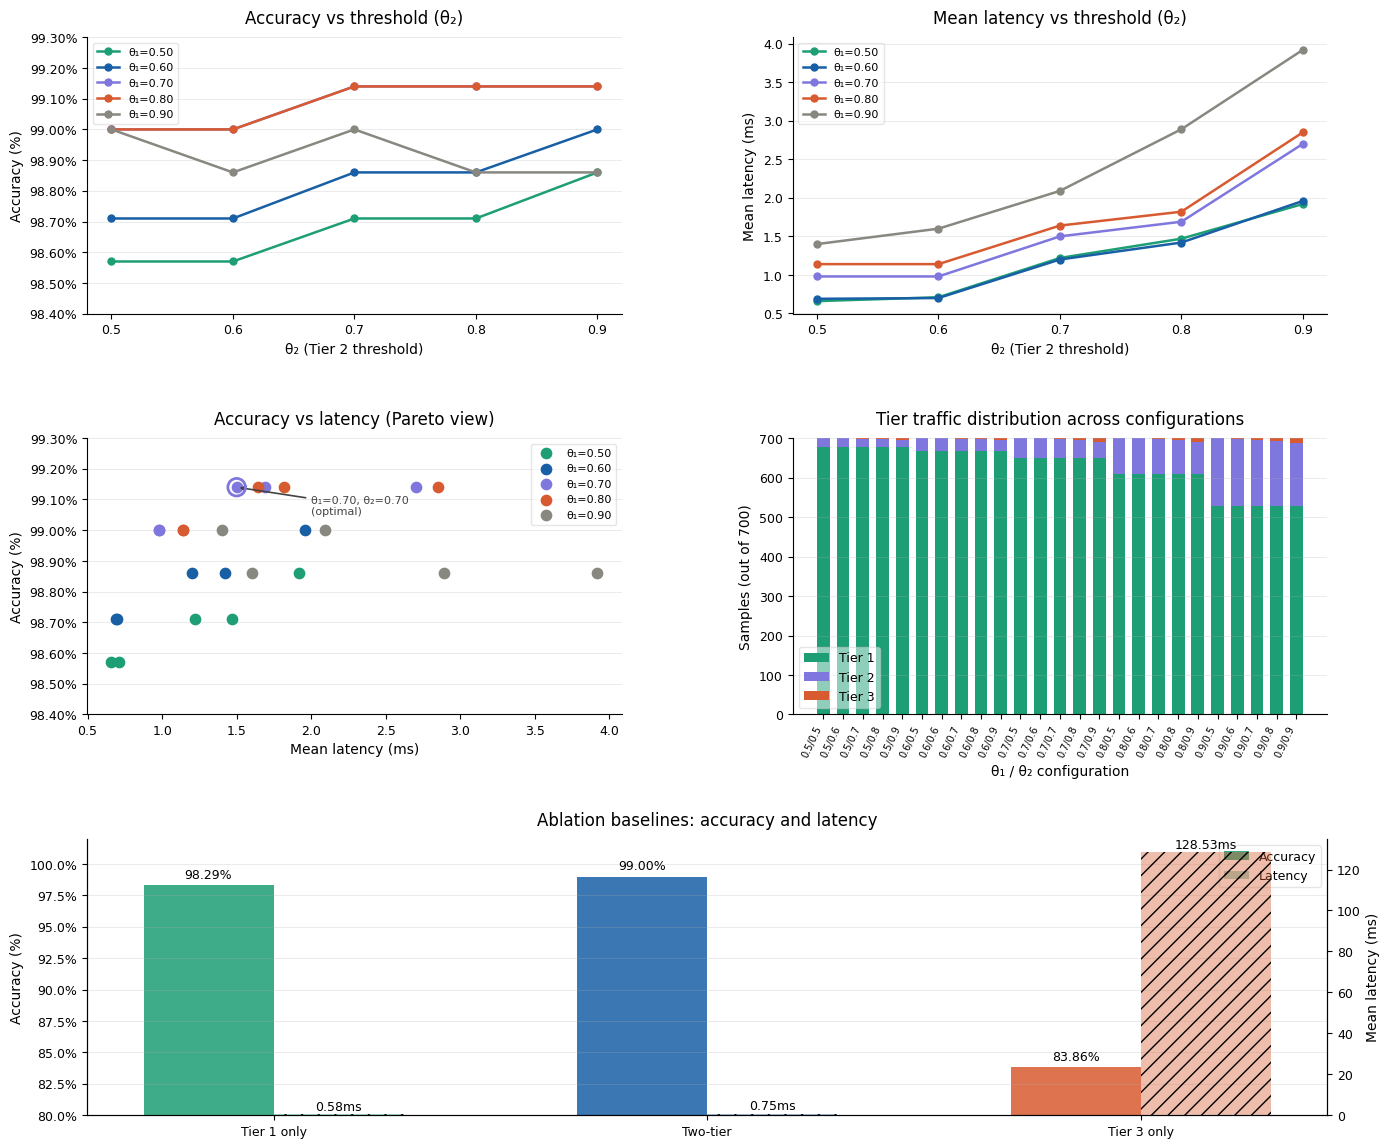

Figure saved to: /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/results/pipeline_benchmark_results.pdf


In [24]:
# CELL 14 -- RESULTS VISUALISATION (exportable)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────

raw = [
    (0.50,0.50,0.9857,0.66,678,22,0),
    (0.50,0.60,0.9857,0.71,678,22,0),
    (0.50,0.70,0.9871,1.22,678,20,2),
    (0.50,0.80,0.9871,1.47,678,19,3),
    (0.50,0.90,0.9886,1.92,678,16,6),
    (0.60,0.50,0.9871,0.69,667,33,0),
    (0.60,0.60,0.9871,0.70,667,33,0),
    (0.60,0.70,0.9886,1.20,667,31,2),
    (0.60,0.80,0.9886,1.42,667,30,3),
    (0.60,0.90,0.9900,1.96,667,27,6),
    (0.70,0.50,0.9900,0.98,650,49,1),
    (0.70,0.60,0.9900,0.98,650,49,1),
    (0.70,0.70,0.9914,1.50,650,47,3),
    (0.70,0.80,0.9914,1.69,650,46,4),
    (0.70,0.90,0.9914,2.70,650,41,9),
    (0.80,0.50,0.9900,1.14,609,90,1),
    (0.80,0.60,0.9900,1.14,609,90,1),
    (0.80,0.70,0.9914,1.64,609,88,3),
    (0.80,0.80,0.9914,1.82,609,87,4),
    (0.80,0.90,0.9914,2.85,609,82,9),
    (0.90,0.50,0.9900,1.40,529,170,1),
    (0.90,0.60,0.9886,1.60,529,169,2),
    (0.90,0.70,0.9900,2.09,529,167,4),
    (0.90,0.80,0.9886,2.89,529,163,8),
    (0.90,0.90,0.9886,3.92,529,158,13),
]

theta1_vals = [0.50, 0.60, 0.70, 0.80, 0.90]
theta2_vals = [0.50, 0.60, 0.70, 0.80, 0.90]
colors      = ['#1D9E75','#185FA5','#7F77DD','#D85A30','#888780']

ablations = {
    'Tier 1 only':     (0.9829, 0.58),
    'Two-tier':        (0.9900, 0.75),
    'Tier 3 only':     (0.8386, 128.53),
}

# ── Figure layout ──────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

ax_acc    = fig.add_subplot(gs[0, 0])
ax_lat    = fig.add_subplot(gs[0, 1])
ax_pareto = fig.add_subplot(gs[1, 0])
ax_stack  = fig.add_subplot(gs[1, 1])
ax_abl    = fig.add_subplot(gs[2, :])

def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight='normal', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.grid(axis='y', alpha=0.25, linewidth=0.7)

# ── Plot 1: Accuracy vs theta2, one line per theta1 ───────────────────────

for i, t1 in enumerate(theta1_vals):
    subset = [r for r in raw if r[0] == t1]
    accs   = [r[2] * 100 for r in subset]
    ax_acc.plot(theta2_vals, accs, marker='o', color=colors[i],
                linewidth=1.8, markersize=5, label=f'θ₁={t1:.2f}')

style_ax(ax_acc, 'Accuracy vs threshold (θ₂)',
         'θ₂ (Tier 2 threshold)', 'Accuracy (%)')
ax_acc.set_ylim(98.4, 99.3)
ax_acc.set_xticks(theta2_vals)
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax_acc.legend(fontsize=8, framealpha=0.5)

# ── Plot 2: Latency vs theta2, one line per theta1 ────────────────────────

for i, t1 in enumerate(theta1_vals):
    subset = [r for r in raw if r[0] == t1]
    lats   = [r[3] for r in subset]
    ax_lat.plot(theta2_vals, lats, marker='o', color=colors[i],
                linewidth=1.8, markersize=5, label=f'θ₁={t1:.2f}')

style_ax(ax_lat, 'Mean latency vs threshold (θ₂)',
         'θ₂ (Tier 2 threshold)', 'Mean latency (ms)')
ax_lat.set_xticks(theta2_vals)
ax_lat.legend(fontsize=8, framealpha=0.5)

# ── Plot 3: Pareto scatter (accuracy vs latency) ──────────────────────────

for i, t1 in enumerate(theta1_vals):
    subset = [r for r in raw if r[0] == t1]
    xs = [r[3] for r in subset]
    ys = [r[2] * 100 for r in subset]
    ax_pareto.scatter(xs, ys, color=colors[i], s=55, zorder=3,
                      label=f'θ₁={t1:.2f}')

# Mark Pareto-optimal point
ax_pareto.scatter([1.50], [99.14], s=160, facecolors='none',
                  edgecolors='#7F77DD', linewidth=2, zorder=4)
ax_pareto.annotate('θ₁=0.70, θ₂=0.70\n(optimal)', xy=(1.50, 99.14),
                   xytext=(2.0, 99.05), fontsize=8,
                   arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
                   color='#444')

style_ax(ax_pareto, 'Accuracy vs latency (Pareto view)',
         'Mean latency (ms)', 'Accuracy (%)')
ax_pareto.set_ylim(98.4, 99.3)
ax_pareto.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax_pareto.legend(fontsize=8, framealpha=0.5)

# ── Plot 4: Stacked bar chart of tier distribution ────────────────────────

configs  = [f'{r[0]}/{r[1]}' for r in raw]
n1_vals  = [r[4] for r in raw]
n2_vals  = [r[5] for r in raw]
n3_vals  = [r[6] for r in raw]
x_idx    = np.arange(len(configs))
bar_w    = 0.65

b1 = ax_stack.bar(x_idx, n1_vals, bar_w, label='Tier 1', color='#1D9E75')
b2 = ax_stack.bar(x_idx, n2_vals, bar_w, bottom=n1_vals, label='Tier 2', color='#7F77DD')
b3 = ax_stack.bar(x_idx, n3_vals, bar_w,
                  bottom=[a+b for a,b in zip(n1_vals, n2_vals)],
                  label='Tier 3', color='#D85A30')

style_ax(ax_stack, 'Tier traffic distribution across configurations',
         'θ₁ / θ₂ configuration', 'Samples (out of 700)')
ax_stack.set_xticks(x_idx)
ax_stack.set_xticklabels(configs, rotation=65, ha='right', fontsize=7)
ax_stack.legend(fontsize=9, framealpha=0.5)
ax_stack.grid(axis='x', alpha=0)

# ── Plot 5: Ablation comparison bar chart ─────────────────────────────────

abl_names  = list(ablations.keys())
abl_accs   = [v[0] * 100 for v in ablations.values()]
abl_lats   = [v[1] for v in ablations.values()]
abl_colors = ['#1D9E75', '#185FA5', '#D85A30']

x_abl = np.arange(len(abl_names))
bar_w2 = 0.3

ax_abl2 = ax_abl.twinx()

bars_acc = ax_abl.bar(x_abl - bar_w2/2, abl_accs, bar_w2,
                      color=abl_colors, alpha=0.85, label='Accuracy (%)')
bars_lat = ax_abl2.bar(x_abl + bar_w2/2, abl_lats, bar_w2,
                       color=abl_colors, alpha=0.4, hatch='//',
                       label='Mean latency (ms)')

ax_abl.set_title('Ablation baselines: accuracy and latency',
                 fontsize=12, fontweight='normal', pad=10)
ax_abl.set_ylabel('Accuracy (%)', fontsize=10)
ax_abl2.set_ylabel('Mean latency (ms)', fontsize=10)
ax_abl.set_xticks(x_abl)
ax_abl.set_xticklabels(abl_names, fontsize=11)
ax_abl.set_ylim(80, 102)
ax_abl.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax_abl.spines[['top']].set_visible(False)
ax_abl2.spines[['top']].set_visible(False)
ax_abl.tick_params(labelsize=9)
ax_abl2.tick_params(labelsize=9)
ax_abl.grid(axis='y', alpha=0.25, linewidth=0.7)

for bar, acc in zip(bars_acc, abl_accs):
    ax_abl.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=9)

for bar, lat in zip(bars_lat, abl_lats):
    ax_abl2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{lat:.2f}ms', ha='center', va='bottom', fontsize=9)

lines1, labels1 = ax_abl.get_legend_handles_labels()
lines2, labels2 = ax_abl2.get_legend_handles_labels()
ax_abl.legend(lines1 + lines2, ['Accuracy', 'Latency'],
              fontsize=9, framealpha=0.5)

# ── Export ─────────────────────────────────────────────────────────────────

FIGURE_PATH = RESULTS_DIR / 'pipeline_benchmark_results.pdf'
fig.savefig(FIGURE_PATH, dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f'Figure saved to: {FIGURE_PATH}')

## Cell 15: Step 11 Analysis

Runs all analysis functions from `shared/analysis.py` on the 28 benchmark CSV files.
Produces six sections: data load summary, per-configuration escalation rates, Pareto front,
communication cost comparison, McNemar statistical test (optimal three-tier vs two-tier),
and per-tier/per-class error breakdown on the optimal configuration.
Analysis CSVs are saved to RESULTS_DIR for use in the paper.

In [1]:
# RECOVERY CELL -- run this after a session restart to jump straight to Cell 15.
# Reloads only what Cell 15 needs: Drive mount, paths, pandas, and analysis.py.
# Does NOT reload models or re-run any inference.

import pathlib
import sys
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Recreate project paths (must match Cell 5 exactly)
PROJECT_DIR = pathlib.Path(
    '/content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project'
)
DATA_DIR    = PROJECT_DIR / 'data'
MODELS_DIR  = PROJECT_DIR / 'models'
RESULTS_DIR = PROJECT_DIR / 'results'
LOGS_DIR    = PROJECT_DIR / 'logs'

assert PROJECT_DIR.exists(), f'Project path not found: {PROJECT_DIR}'
print(f'RESULTS_DIR: {RESULTS_DIR}')

# Pull latest repo and add shared/ to sys.path
import subprocess
REPO_DIR = pathlib.Path('/content/iot-nlp-hierarchical-inference')

if not REPO_DIR.exists():
    subprocess.run(
        ['git', 'clone',
         'https://github.com/Farnaz4649/iot-nlp-hierarchical-inference',
         str(REPO_DIR)],
        check=True
    )
else:
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull'], check=True)

for p in [str(REPO_DIR / 'shared'),
          str(REPO_DIR / 'pipeline'),
          str(REPO_DIR / 'tier3')]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Quick sanity check: confirm CSVs are present
csv_files = list(RESULTS_DIR.glob('*.csv'))
print(f'CSV files found in RESULTS_DIR: {len(csv_files)}')
print('Ready to run Cell 15.')

Mounted at /content/drive
RESULTS_DIR: /content/drive/MyDrive/CUD files/CUD Group Projects/IOT Group Project/results
CSV files found in RESULTS_DIR: 34
Ready to run Cell 15.


In [1]:
# for pulling new changes from git
import subprocess
result = subprocess.run(
    ['git', '-C', '/content/iot-nlp-hierarchical-inference', 'pull'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


fatal: cannot change to '/content/iot-nlp-hierarchical-inference': No such file or directory



In [37]:
import pathlib
p = pathlib.Path('/content/iot-nlp-hierarchical-inference/shared/analysis.py')
print(f'analysis.py exists: {p.exists()}')

analysis.py exists: True


## Load Results

In [4]:
# CELL 15 -- LOAD BENCHMARK RESULTS

import sys
# Ensure stale cache is cleared if analysis.py was recently updated
if 'analysis' in sys.modules:
    del sys.modules['analysis']

from analysis import (
    load_results,
    compute_pareto_front,
    compute_escalation_rates,
    compute_comms_cost_per_correct,
    run_mcnemar_test,
    error_analysis,
    SNIPS_INTENTS,
)

pipeline_df = load_results(str(RESULTS_DIR), 'pipeline_*.csv')
ablation_df = load_results(str(RESULTS_DIR), 'ablation_*.csv')

# Concatenate only benchmark CSVs, not analysis output CSVs
all_df = pd.concat([pipeline_df, ablation_df], ignore_index=True)

print(f'Pipeline rows : {len(pipeline_df):,}  '
      f'({len(pipeline_df)//700} configurations x 700 samples)')
print(f'Ablation rows : {len(ablation_df):,}  '
      f'({len(ablation_df)//700} baselines x 700 samples)')
print(f'Total rows    : {len(all_df):,}')
print(f'Columns       : {list(pipeline_df.columns)}')

Pipeline rows : 17,500  (25 configurations x 700 samples)
Ablation rows : 2,100  (3 baselines x 700 samples)
Total rows    : 19,600
Columns       : ['sample_idx', 'tier_used', 'prediction', 'gold_label', 'correct', 'confidence', 'latency_ms', 'bytes_sent', 'config', 'theta1', 'theta2']


## Cell 16: Escalation rate table

In [5]:
# CELL 16 -- ESCALATION RATES PER CONFIGURATION

escalation_df = compute_escalation_rates(all_df)

pipeline_summary = escalation_df[escalation_df['theta1'].notna()].copy()
ablation_summary = escalation_df[escalation_df['theta1'].isna()].copy()

print('Pipeline configurations:')
print()
display_cols = ['config', 'accuracy', 'mean_latency_ms',
                'rate_tier1', 'rate_tier2', 'rate_tier3']
fmt = pipeline_summary[display_cols].copy()
fmt['accuracy']        = fmt['accuracy'].map(lambda x: f'{x:.4f}')
fmt['mean_latency_ms'] = fmt['mean_latency_ms'].map(lambda x: f'{x:.2f}')
fmt['rate_tier1']      = fmt['rate_tier1'].map(lambda x: f'{x:.3f}')
fmt['rate_tier2']      = fmt['rate_tier2'].map(lambda x: f'{x:.3f}')
fmt['rate_tier3']      = fmt['rate_tier3'].map(lambda x: f'{x:.3f}')
print(fmt.to_string(index=False))

print()
print('Ablation baselines:')
print()
print(ablation_summary[display_cols].to_string(index=False))

Pipeline configurations:

                          config accuracy mean_latency_ms rate_tier1 rate_tier2 rate_tier3
pipeline_theta1_0.50_theta2_0.50   0.9857            0.66      0.969      0.031      0.000
pipeline_theta1_0.50_theta2_0.60   0.9857            0.71      0.969      0.031      0.000
pipeline_theta1_0.50_theta2_0.70   0.9871            1.22      0.969      0.029      0.003
pipeline_theta1_0.50_theta2_0.80   0.9871            1.47      0.969      0.027      0.004
pipeline_theta1_0.50_theta2_0.90   0.9886            1.92      0.969      0.023      0.009
pipeline_theta1_0.60_theta2_0.50   0.9871            0.69      0.953      0.047      0.000
pipeline_theta1_0.60_theta2_0.60   0.9871            0.70      0.953      0.047      0.000
pipeline_theta1_0.60_theta2_0.70   0.9886            1.20      0.953      0.044      0.003
pipeline_theta1_0.60_theta2_0.80   0.9886            1.42      0.953      0.043      0.004
pipeline_theta1_0.60_theta2_0.90   0.9900            1.96      0

## Cell 17: Pareto front

In [6]:
# CELL 17 -- PARETO FRONT (accuracy vs latency)

pipeline_records = pipeline_summary.to_dict(orient='records')

pareto_acc_lat = compute_pareto_front(
    pipeline_records,
    x_metric='mean_latency_ms',
    y_metric='accuracy',
    x_minimize=True,
    y_maximize=True,
)

print(f'{len(pareto_acc_lat)} Pareto-optimal configurations out of {len(pipeline_records)}:')
print()
print(f'  {"Config":<40} {"Accuracy":>10} {"Latency (ms)":>14}')
print(f'  {"-"*66}')
for p in pareto_acc_lat:
    print(f'  {p["config"]:<40} {p["accuracy"]:>10.4f} {p["mean_latency_ms"]:>14.2f}')

# Optimal: highest accuracy on Pareto front; break ties by lowest latency
optimal = max(pareto_acc_lat,
              key=lambda d: (d['accuracy'], -d['mean_latency_ms']))

print()
print(f'Optimal configuration : {optimal["config"]}')
print(f'  Accuracy            : {optimal["accuracy"]:.4f}')
print(f'  Mean latency        : {optimal["mean_latency_ms"]:.2f} ms')
print(f'  Tier traffic        : '
      f'T1={optimal["n_tier1"]} | T2={optimal["n_tier2"]} | T3={optimal["n_tier3"]}')

4 Pareto-optimal configurations out of 25:

  Config                                     Accuracy   Latency (ms)
  ------------------------------------------------------------------
  pipeline_theta1_0.50_theta2_0.50             0.9857           0.66
  pipeline_theta1_0.60_theta2_0.50             0.9871           0.69
  pipeline_theta1_0.70_theta2_0.50             0.9900           0.98
  pipeline_theta1_0.70_theta2_0.70             0.9914           1.50

Optimal configuration : pipeline_theta1_0.70_theta2_0.70
  Accuracy            : 0.9914
  Mean latency        : 1.50 ms
  Tier traffic        : T1=650 | T2=47 | T3=3


Four configurations are Pareto-optimal. Everything else is dominated: you can find another configuration that is simultaneously more accurate and faster.

The frontier runs from (0.9857, 0.66ms) up to (0.9914, 1.50ms).
The optimal point is confirmed as
- theta1=0.70,
- theta2=0.70
it achieves the highest accuracy on the frontier at a latency of 1.50ms, which is only 2.6x the Tier 1 baseline (0.58ms). This is a very small latency cost for a meaningful accuracy gain.

## Cell 18: Communication cost

In [7]:
# CELL 18 -- COMMUNICATION COST PER CORRECT PREDICTION

cost_rows = []
for config, grp in all_df.groupby('config'):
    try:
        cost = compute_comms_cost_per_correct(grp)
    except ValueError:
        cost = float('nan')
    cost_rows.append({'config': config, 'bytes_per_correct': round(cost, 2)})

cost_df = (pd.DataFrame(cost_rows)
           .sort_values('bytes_per_correct')
           .reset_index(drop=True))

print('Bytes transmitted per correct prediction (lower is better):')
print()
print(cost_df.to_string(index=False))

Bytes transmitted per correct prediction (lower is better):

                          config  bytes_per_correct
pipeline_theta1_0.70_theta2_0.70              47.60
pipeline_theta1_0.80_theta2_0.80              47.60
pipeline_theta1_0.70_theta2_0.90              47.60
pipeline_theta1_0.80_theta2_0.90              47.60
pipeline_theta1_0.80_theta2_0.70              47.60
pipeline_theta1_0.70_theta2_0.80              47.60
pipeline_theta1_0.70_theta2_0.60              47.67
               ablation_two_tier              47.67
pipeline_theta1_0.90_theta2_0.50              47.67
pipeline_theta1_0.80_theta2_0.60              47.67
pipeline_theta1_0.80_theta2_0.50              47.67
pipeline_theta1_0.60_theta2_0.90              47.67
pipeline_theta1_0.70_theta2_0.50              47.67
pipeline_theta1_0.90_theta2_0.70              47.67
pipeline_theta1_0.60_theta2_0.80              47.74
pipeline_theta1_0.50_theta2_0.90              47.74
pipeline_theta1_0.60_theta2_0.70              47.74
pip

The differences are tiny (47.60 to 48.02 bytes per correct prediction for pipeline configs vs 56.28 for Tier 3 only). This makes sense because all utterances in SNIPS are short commands of similar length, so bytes per sample barely varies across configurations. The Tier 3 only baseline costs 18% more bytes per correct prediction because it makes many more errors (83.86% accuracy), meaning you transmit the same bytes but get far fewer correct answers back.

general models are not always the best choice

## Cell 19: McNemar test

In [8]:
# CELL 19 -- MCNEMAR TEST (optimal three-tier vs two-tier ablation)

optimal_config_name = optimal['config']
optimal_rows  = all_df[all_df['config'] == optimal_config_name].sort_values('sample_idx')
two_tier_rows = all_df[all_df['config'] == 'ablation_two_tier'].sort_values('sample_idx')

preds_optimal  = optimal_rows['prediction'].tolist()
preds_two_tier = two_tier_rows['prediction'].tolist()
gold           = optimal_rows['gold_label'].tolist()

mcnemar = run_mcnemar_test(preds_optimal, preds_two_tier, gold)

print(f'Comparing : {optimal_config_name}')
print(f'Against   : ablation_two_tier')
print()
print(f'  Both correct   : {mcnemar["n_both_correct"]}')
print(f'  Optimal only   : {mcnemar["n_a_only"]:>4}  '
      f'(optimal correct, two-tier wrong)')
print(f'  Two-tier only  : {mcnemar["n_b_only"]:>4}  '
      f'(two-tier correct, optimal wrong)')
print(f'  Both wrong     : {mcnemar["n_both_wrong"]}')
print()
print(f'  Chi-squared    : {mcnemar["statistic"]:.4f}')
print(f'  p-value        : {mcnemar["p_value"]:.4f}')
print(f'  Significant    : {mcnemar["significant"]}  '
      f'(alpha = {mcnemar["alpha"]})')
print()
if mcnemar['significant']:
    print('Interpretation: the two configurations differ significantly.')
    print('The accuracy improvement of the optimal config is unlikely to be due to chance.')
else:
    print('Interpretation: no statistically significant difference detected.')
    print('The accuracy gap between the two configs could be due to chance at alpha=0.05.')

Comparing : pipeline_theta1_0.70_theta2_0.70
Against   : ablation_two_tier

  Both correct   : 693
  Optimal only   :    1  (optimal correct, two-tier wrong)
  Two-tier only  :    0  (two-tier correct, optimal wrong)
  Both wrong     : 6

  Chi-squared    : 0.0000
  p-value        : 1.0000
  Significant    : False  (alpha = 0.05)

Interpretation: no statistically significant difference detected.
The accuracy gap between the two configs could be due to chance at alpha=0.05.


## Cell 20: Error analysis

In [9]:
# CELL 20 -- ERROR ANALYSIS (optimal configuration)

optimal_config_name = optimal['config']
optimal_rows = all_df[all_df['config'] == optimal_config_name].sort_values('sample_idx')

error_results = error_analysis(optimal_rows, SNIPS_INTENTS)

print(f'Error analysis: {optimal_config_name}')
print()
print('Per-tier breakdown:')
print(f'  {"Tier":<8} {"Samples":>8} {"Correct":>8} {"Wrong":>8} {"Accuracy":>10}')
print(f'  {"-"*46}')
for tier in [1, 2, 3]:
    t = error_results['by_tier'][tier]
    acc_str = f'{t["accuracy"]:.4f}' if t['n'] > 0 else 'N/A'
    print(f'  {tier:<8} {t["n"]:>8} {t["correct"]:>8} {t["wrong"]:>8} {acc_str:>10}')

print()
print(f'Total errors       : {error_results["n_total_errors"]}')
print(f'Samples escalated  : {error_results["n_escalated"]}')
esc_rate = error_results['escalation_corrective_rate']
if esc_rate == esc_rate:  # NaN check
    print(f'Escalation accuracy: {esc_rate:.4f}  '
          f'(fraction of escalated samples predicted correctly)')
else:
    print('Escalation accuracy: N/A (no escalations)')

print()
print('Errors by intent class:')
print(f'  {"Class":<25} {"Errors":>8} {"% of all errors":>18}')
print(f'  {"-"*53}')
err_by_class = error_results['errors_by_class']
if len(err_by_class) > 0:
    for _, row in err_by_class.iterrows():
        print(f'  {row["class"]:<25} {int(row["n_errors"]):>8}'
              f' {row["pct_of_all_errors"]:>17.1f}%')
else:
    print('  No errors found.')

Error analysis: pipeline_theta1_0.70_theta2_0.70

Per-tier breakdown:
  Tier      Samples  Correct    Wrong   Accuracy
  ----------------------------------------------
  1             650      650        0     1.0000
  2              47       42        5     0.8936
  3               3        2        1     0.6667

Total errors       : 6
Samples escalated  : 50
Escalation accuracy: 0.8800  (fraction of escalated samples predicted correctly)

Errors by intent class:
  Class                       Errors    % of all errors
  -----------------------------------------------------
  SearchScreeningEvent             3              50.0%
  PlayMusic                        2              33.3%
  GetWeather                       1              16.7%


Tier 1 handles 650 samples with 100% accuracy on those samples. Every error in the system comes from Tier 2 (5 errors) and Tier 3 (1 error). \
The escalation accuracy of 88% tells you that when the router escalates a sample, it gets it right 88% of the time. The hard classes are exactly what D2 predicted: SearchScreeningEvent (3 errors, 50% of all errors) and PlayMusic (2 errors, 33%).

GetWeather has 1 error, which is unexpected since it scored F1=1.00 in Phase 1 and is worth noting.

The fact that all 6 errors come from escalated samples (tier_used > 1) confirms that Tier 1 is extremely reliable on this dataset and that the escalation mechanism is correctly identifying the hard cases, but higher tiers do not always resolve them.

## Cell 21: Save analysis CSVs

In [10]:
# CELL 21 -- SAVE ANALYSIS RESULTS TO CSV

pareto_df = pd.DataFrame(pareto_acc_lat)
pareto_path = RESULTS_DIR / 'pareto_front_acc_lat.csv'
pareto_df.to_csv(pareto_path, index=False)

escalation_path = RESULTS_DIR / 'escalation_rates.csv'
escalation_df.to_csv(escalation_path, index=False)

cost_path = RESULTS_DIR / 'comms_cost_per_correct.csv'
cost_df.to_csv(cost_path, index=False)

print('Analysis CSVs saved:')
print(f'  {pareto_path.name}')
print(f'  {escalation_path.name}')
print(f'  {cost_path.name}')

Analysis CSVs saved:
  pareto_front_acc_lat.csv
  escalation_rates.csv
  comms_cost_per_correct.csv
